In [10]:
%%configure -f
{
    "driverMemory": "16G", "driverCores": 8,
    "executorMemory": "8G", "executorCores": 6, "numExecutors": 3,
    "heartbeatTimeoutInSecond": 3600
}

Starting Spark application


ID,YARN Application ID,Kind,State,Spark UI,Driver log,User,Current session?
2,None,pyspark,idle,,,None,✔


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

SparkSession available as 'spark'.


ID,YARN Application ID,Kind,State,Spark UI,Driver log,User,Current session?
2,None,pyspark,idle,,,None,✔


In [9]:
from typing import List

from pyspark import SparkFiles
from subprocess import call
import sys


def install_deps(deps: List[str]) -> None:
    call([sys.executable, '-m', 'pip', 'install', '-q', '-t', SparkFiles.getRootDirectory(), *deps])


install_deps(['numpy', 'matplotlib', 'pandas', 'scipy', 'seaborn', 'statsmodels', 'pyarrow', 'pymongo'])

An error was encountered:
Invalid status code '404' from http://livy:8998/sessions/1 with error payload: {"msg":"Session '1' not found."}


In [17]:
from pyspark.sql import functions as F, types as T
import numpy as np
from scipy import stats
from statsmodels.sandbox.stats.multicomp import multipletests

@F.udf(T.ArrayType(T.DoubleType()))
def diff(A, B):
    return np.abs(np.array(A) - np.array(B)).tolist()

@F.udf(T.DoubleType())
def var(A):
    return float(np.var(A))

@F.udf(T.DoubleType())
def avg(A):
    return float(np.mean(A))

@F.udf(T.DoubleType())
def mannwhiteneyu(ref, mod):
    result = stats.mannwhitneyu(np.array(ref), np.array(mod), alternative='two-sided')
    return float(result.pvalue)

@F.udf(T.DoubleType())
def bonferroni_correction(pvalues, alpha=0.05):
    reject, pvals_corrected, _, _ = multipletests(pvalues, alpha=alpha, method='bonferroni')
    return float(np.mean(pvals_corrected))


FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

An error was encountered:
No module named 'numpy'
Traceback (most recent call last):
ModuleNotFoundError: No module named 'numpy'



In [11]:
from pyspark import SparkContext
from pyspark.sql import SparkSession

sc: SparkContext
spark: SparkSession

project_configuration_df = (
    spark
    .read
    .json("s3a://database/project_configuration", multiLine=True)
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [13]:
%%pretty
project_configuration_df

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

configuration,datasets,project,project_id
"{NULL, 10000}",[{enhanceratlas2_...,"{[Nikita Kozlov, ...",8k_models_project...
"{NULL, 10000}",[{enhanceratlas2_...,"{[Nikita Kozlov, ...",8k_models_project...
"{NULL, 10000}",[{enhanceratlas2_...,"{[Nikita Kozlov, ...",8k_models_project...
"{NULL, 10000}",[{enhanceratlas2_...,"{[Nikita Kozlov, ...",8k_models_project...


In [22]:
ensembles_list_by_project_df = (
    project_configuration_df
    .select(F.col('project_id'), F.col('datasets.ensemble_id').alias('ensemble_id'), F.col('datasets.metadata.cell_line').alias('cell_line'))
    .select('project_id', F.explode('ensemble_id').alias('ensemble_id'), F.explode('cell_line').alias('cell_line'))
    .where(F.col('cell_line') == 'GM12878')
)

ensembles_list_by_project_df.show()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+--------------------+--------------------+---------+
|          project_id|         ensemble_id|cell_line|
+--------------------+--------------------+---------+
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models3D_GM12878_...|  GM12878|
|8k_models_project...|models

In [30]:
all_relevant_ensembles_df_deni = (
    ensembles_list_by_project_df
    .where(
        (
            (F.col('project_id').isin(['8k_models_project_GM12878']))
            & (F.col('ensemble_id').like('models3D_GM12878_Deni_models3D_GM12878_Deni_results%'))
        )
        | (
            (F.col('project_id').isin(['8k_models_project_HFFC6']))
            & (F.col('ensemble_id').like('models3D_HFFC6_Deni_models3D_HFFC6_Deni_results%'))
        )
        | (
            (F.col('project_id').isin(['8k_models_project_H1ESC']))
            & (F.col('ensemble_id').like('models3D_H1ESC_Deni_models3D_H1ESC_Deni_results%'))
        )
        | (
            (F.col('project_id').isin(['8k_models_project_GM12878']))
            & (F.col('ensemble_id').like('models3D_GM12878_Deni_models3D_GM12878_Deni_results%'))
        )
    )
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [40]:
all_relevant_ensembles_df_deni.show()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

+--------------------+--------------------+
|          project_id|         ensemble_id|
+--------------------+--------------------+
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_GM12878_...|
|8k_models_project...|models3D_G

In [31]:
distances_df = (
    spark
    .read
    .parquet("s3a://database/distance_calculation")
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [35]:
distances_df.printSchema()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

root
 |-- region_id: string (nullable = true)
 |-- region_chr: string (nullable = true)
 |-- region_start: long (nullable = true)
 |-- region_end: long (nullable = true)
 |-- gene_id: string (nullable = true)
 |-- gene_type: string (nullable = true)
 |-- gene_chr: string (nullable = true)
 |-- gene_start: long (nullable = true)
 |-- gene_end: long (nullable = true)
 |-- gene_strand: string (nullable = true)
 |-- gene_model_position: long (nullable = true)
 |-- gene_model_coloring_start: long (nullable = true)
 |-- gene_model_coloring_end: long (nullable = true)
 |-- gene_TSS_pos: long (nullable = true)
 |-- enh_id: string (nullable = true)
 |-- enh_chr: string (nullable = true)
 |-- enh_start: long (nullable = true)
 |-- enh_end: long (nullable = true)
 |-- enh_score: double (nullable = true)
 |-- enh_center_position: long (nullable = true)
 |-- enh_model_position: long (nullable = true)
 |-- enh_model_coloring_start: long (nullable = true)
 |-- enh_model_coloring_end: long (nullable =

In [41]:
distances_query_deni_df = (
    distances_df
    .where(
        (
            (F.col('project_id').isin(['8k_models_project_GM12878']))
            & (F.col('ensemble_id').like('models3D_GM12878_Deni_models3D_GM12878_Deni_results%'))
        )
        | (
            (F.col('project_id').isin(['8k_models_project_HFFC6']))
            & (F.col('ensemble_id').like('models3D_HFFC6_Deni_models3D_HFFC6_Deni_results%'))
        )
        | (
            (F.col('project_id').isin(['8k_models_project_H1ESC']))
            & (F.col('ensemble_id').like('models3D_H1ESC_Deni_models3D_H1ESC_Deni_results%'))
        )
        | (
            (F.col('project_id').isin(['8k_models_project_GM12878']))
            & (F.col('ensemble_id').like('models3D_GM12878_Deni_models3D_GM12878_Deni_results%'))
        )
    )
    .select(
        F.col('project_id'),
        F.col('ensemble_id'),
        F.col('region_id'),
        F.col('gene_id'),
        F.col('enh_id'),
        F.col('gene_type'),
        F.col('avg_dist'),
        F.col('enh_tSS_distance'),
        F.col('project_cell_lines'),
        F.col('region_chr'),
        F.col('region_start'),
        F.col('region_end')
    )
    .where(
        (F.col('gene_type') == 'protein_coding')
        # & (F.col('enh_tSS_distance') < 20_000)
    )
    .select(
        F.col('project_id'),
        F.col('ensemble_id'),
        F.col('region_id'),
        F.col('gene_id'),
        F.col('enh_id'),
        F.element_at(F.col('project_cell_lines'), 1).alias('cell_line'),
        # 'dist',
        'avg_dist',
        'enh_tSS_distance',
        'region_chr',
        'region_start',
        'region_end'
    )
    # gene_id ENH00001.XXX -> ENH00001
    .withColumn('gene_id', F.split(F.col('gene_id'), '\.')[0])
    # add region size = region_end - region_start
    .withColumn('region_size', F.col('region_end') - F.col('region_start'))
    # count the number of gene-enh pairs per cell line and region
    .groupBy('cell_line', 'region_id')
    .agg(
        F.count(F.lit(1)).alias('gene_enh_pairs_count'),
        F.first('region_size').alias('region_size'),
    )
)

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

<stdin>:54: SyntaxWarning: invalid escape sequence '\.'

In [42]:
distances_query_deni_pandas_df = distances_query_deni_df.toPandas()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

def densplot(cell_line=None, fontsize=24):
    if cell_line is None:
        data = distances_query_deni_pandas_df
    else:
        data = distances_query_deni_pandas_df[distances_query_deni_pandas_df['cell_line'] == cell_line]
    # Density plot for the number of gene-enh pairs per cell line and region size
    plt.figure(figsize=(12, 5))
    sns.histplot(
        data=data[['cell_line', 'region_size', 'gene_enh_pairs_count']],
        weights='gene_enh_pairs_count',
        x='region_size',
        hue='cell_line',
        fill=True,
        common_norm=False,
        linestyle='-',
        alpha=0.1,
        legend=True,
        kde=True,
        kde_kws={
            'bw_adjust': 0.2,  # Adjust the bandwidth for smoother KDE
            'cut': 0,  # No extrapolation beyond the data range
        },
    )

    sns.move_legend(
        plt.gca(),
        "upper right",
        title="Cell Line",
        frameon=True,
        fontsize=fontsize / 1.5,
    )

    ax = plt.gca()
    ax.ticklabel_format(style='plain', axis='both')

    from matplotlib.ticker import FuncFormatter
    def format_x(x, pos):
        if x >= 1_000_000:
            return f'{int(x/1_000_000)}M'
        elif x >= 1_000:
            return f'{int(x/1_000)}K'
        return str(int(x))

    ax.xaxis.set_major_formatter(FuncFormatter(format_x))

    plt.title('Gene-Enhancer Pairs Count by Model Ensemble Region Size', fontsize=fontsize)
    plt.xlabel('Region Size (bp)', fontsize=fontsize)
    plt.ylabel('Number of Pairs', fontsize=fontsize)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('/work/playground/figs/gene_enh_pairs_density_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

FloatProgress(value=0.0, bar_style='info', description='Progress:', layout=Layout(height='25px', width='50%'),…

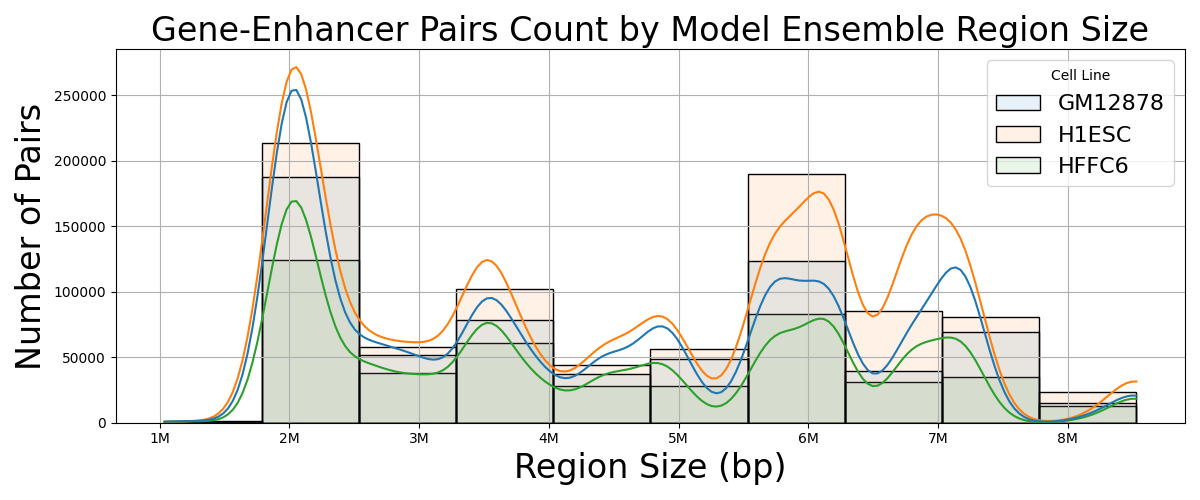

In [44]:
densplot()
%matplot plt